# Unidad 4 · Análisis de sentimiento y tendencias en redes sociales — Integración con APIs y Análisis Avanzado

Asignatura: Búsqueda y Análisis de la Información.    
Alumno: Rodrigo de Siqueira-Lima Pérez-Moreno

## Descripción

Esta entrega es la continuación de la práctica de la Unidad 2. Sobre la clase `DataExtractor` que ya tenía hecha he añadido:

- Extracción de tweets en tiempo real desde la API de Twitter (twitter-api45 en RapidAPI), con bucle paginado para aprovechar la cuota.
- Modelado de tópicos con LDA usando gensim.
- Análisis de sentimiento con TextBlob y, además, VADER para comparar.
- Un resumen extractivo del corpus.

### Datos

La fuente principal del análisis es la API. Como respaldo dejo el dataset de Bitcoin Tweets de Kaggle (`data/bronze/Bitcoin_tweets_dataset_2.csv`) por si la cuota de la API se agotara.

Toda la lógica vive dentro de la clase `DataExtractor`.

## Librerías

In [84]:
import os
import re
import csv
import json
import requests
import polars as pl
import matplotlib.pyplot as plt
import nltk
from datetime import datetime
from pathlib import Path
from dotenv import load_dotenv
from gensim import corpora
from gensim.models import LdaModel, Phrases
from gensim.models.phrases import Phraser
from gensim.models.coherencemodel import CoherenceModel
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)


True

## Clase `DataExtractor`

In [85]:
class DataExtractor:
    extra_stopwords = {
        'rt', 'amp', 'via', 'u', 'im', 'dont', 'cant', 'gonna', 'wanna', 'lol',
        'ur', 'w', 's', 'get', 'got', 'one', 'like', 'go', 'going', 'see', 'use',
        'new', 'day', 'time', 'year', 'week', 'way', 'even', 'good', 'know',
        'still', 'back', 'also',
    }
    crypto_core = {'bitcoin', 'btc', 'crypto', 'cryptocurrency'}

    def __init__(self, source=None, data_root='data'):
        self.source = source
        self.data   = None
        self.data_root  = Path(data_root)
        self.bronze_dir = self.data_root / 'bronze'
        self.silver_dir = self.data_root / 'silver'
        self.gold_dir   = self.data_root / 'gold'
        for d in (self.bronze_dir, self.silver_dir, self.gold_dir):
            d.mkdir(parents=True, exist_ok=True)
        self.next_cursor = None
        nltk_sw = set(nltk.corpus.stopwords.words('english'))
        self.stopwords_keywords = nltk_sw | self.extra_stopwords | self.crypto_core
        self.stopwords_lda      = nltk_sw | self.extra_stopwords

    def load_data_api(self, query, max_results=100, output_file=None):
        load_dotenv()
        api_key = os.getenv('RAPIDAPI_KEY')
        if not api_key:
            raise ValueError('Falta RAPIDAPI_KEY en .env')
        if output_file is None:
            output_file = str(self.bronze_dir / 'tweets_from_api.csv')

        url = 'https://twitter-api45.p.rapidapi.com/search.php'
        headers = {'x-rapidapi-host': 'twitter-api45.p.rapidapi.com', 'x-rapidapi-key': api_key}

        tweets = []
        while len(tweets) < max_results:
            params = {'query': query, 'search_type': 'Top'}
            if self.next_cursor:
                params['cursor'] = self.next_cursor
            resp = requests.get(url, headers=headers, params=params, timeout=15)
            try:
                resp.raise_for_status()
                data = resp.json()
            except (requests.HTTPError, ValueError) as e:
                print(f'  Aviso: respuesta no valida ({e}). Paro la descarga.')
                break
            batch = data.get('timeline', [])
            if not batch:
                break
            tweets.extend(batch)
            self.next_cursor = data.get('next_cursor')
            if not self.next_cursor:
                break

        tweets = tweets[:max_results]
        if not tweets:
            print('La API no devolvio tweets en esta llamada.')
            return self.data

        rows = []
        for t in tweets:
            user_info = t.get('user_info', {})
            raw_date  = t.get('created_at', '')
            try:
                iso_date = datetime.strptime(raw_date, '%a %b %d %H:%M:%S %z %Y').strftime('%Y-%m-%d %H:%M:%S')
            except (ValueError, TypeError):
                iso_date = raw_date
            rows.append({
                'user_name':      t.get('screen_name', ''),
                'date':           iso_date,
                'text':           t.get('text', ''),
                'tweet_id':       str(t.get('tweet_id', '')),
                'user_followers': user_info.get('followers_count'),
                'is_retweet':     str(t.get('text', '')).startswith('RT '),
            })

        # Append con csv stdlib (polars no soporta modo append)
        file_exists = Path(output_file).exists()
        with open(output_file, 'a', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=rows[0].keys())
            if not file_exists:
                writer.writeheader()
            writer.writerows(rows)

        full = pl.read_csv(output_file, infer_schema_length=None)
        self.data   = full
        self.source = output_file
        print(f'{len(rows)} nuevos. Total acumulado en "{output_file}": {len(full)}')
        return full

    def load_data(self):
        if self.source is None:
            raise ValueError('No hay archivo fuente.')
        if self.source.endswith('.csv'):
            self.data = (
                pl.scan_csv(self.source, encoding='utf8', infer_schema_length=None)
                .collect()
            )
        elif self.source.endswith('.json'):
            self.data = pl.read_ndjson(self.source)
        else:
            raise ValueError('Formato no soportado. Usa CSV o JSON.')
        return self.data

    def clean_text(self, text):
        if not isinstance(text, str):
            return ''
        text = text.lower()
        text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
        text = re.sub(r'@\w+', ' ', text)
        text = re.sub(r'[^0-9a-z#\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def extract_hashtags(self, text):
        if not isinstance(text, str):
            return []
        return re.findall(r'#\w+', text)

    def extract_keywords(self, text, min_length=3):
        if not isinstance(text, str) or not text.strip():
            return []
        return [
            w for w in text.split()
            if len(w) >= min_length
            and w not in self.stopwords_keywords
            and not w.startswith('#')
            and not w.isdigit()
        ]

    def analytics_keywords(self, top_n=30):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        return (
            df.with_columns(
                pl.col('text').map_elements(self.clean_text, return_dtype=pl.String).alias('clean')
            ).with_columns(
                pl.col('clean').map_elements(self.extract_keywords, return_dtype=pl.List(pl.String)).alias('keywords')
            ).explode('keywords')
            .filter(pl.col('keywords').is_not_null())
            .filter(pl.col('keywords').str.strip_chars() != '')
            .group_by('keywords')
            .agg(pl.len().alias('frequency'))
            .rename({'keywords': 'keyword'})
            .sort('frequency', descending=True)
            .head(top_n)
        )

    def model_topics(self, num_topics=5, passes=10, sample_size=None,
                     use_bigrams=True, compute_coherence=True):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        if 'clean_text' not in df.columns:
            df = df.with_columns(
                pl.col('text').map_elements(self.clean_text, return_dtype=pl.String).alias('clean_text')
            )
        if sample_size is not None and sample_size < len(df):
            df = df.sample(n=sample_size, seed=42)

        def filter_tokens(tokens):
            return [
                w for w in tokens
                if w not in self.stopwords_lda
                and len(w) > 2
                and not w.isdigit()
                and not w.startswith('http')
            ]

        texts  = df['clean_text'].drop_nulls().to_list()
        tokens = [filter_tokens(t.split()) for t in texts]
        tokens = [t for t in tokens if t]

        if use_bigrams:
            bigram_model   = Phrases(tokens, min_count=10, threshold=20)
            bigram_phraser = Phraser(bigram_model)
            tokens = [bigram_phraser[t] for t in tokens]

        dictionary = corpora.Dictionary(tokens)
        dictionary.filter_extremes(no_below=5, no_above=0.5)
        corpus = [dictionary.doc2bow(doc) for doc in tokens]

        lda = LdaModel(corpus, num_topics=num_topics, id2word=dictionary,
                       passes=passes, random_state=42)

        topics = []
        for topic_id in range(num_topics):
            words = [w for w, _ in lda.show_topic(topic_id, topn=10)]
            topics.append(words)

        coherence = None
        if compute_coherence:
            try:
                coherence = CoherenceModel(
                    model=lda, texts=tokens, dictionary=dictionary, coherence='c_v'
                ).get_coherence()
            except Exception as e:
                print(f'No se pudo calcular la coherencia: {e}')

        out = {f'topic_{i}': words for i, words in enumerate(topics)}
        out['_coherence_c_v'] = coherence
        (self.gold_dir / 'topics_lda.json').write_text(
            json.dumps(out, indent=2, ensure_ascii=False)
        )
        return {'topics': topics, 'coherence': coherence}

    def analyze_sentiment(self, method='textblob', sample_size=None):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        text_col = 'clean_text' if 'clean_text' in df.columns else 'text'
        if sample_size is not None and sample_size < len(df):
            df = df.sample(n=sample_size, seed=42)

        if method == 'textblob':
            texts = df[text_col].fill_null('').to_list()
            sents = [TextBlob(t).sentiment for t in texts]
            df = df.with_columns([
                pl.Series('sentiment_polarity',    [s.polarity     for s in sents]),
                pl.Series('sentiment_subjectivity', [s.subjectivity for s in sents]),
            ])
        elif method == 'vader':
            analyzer = SentimentIntensityAnalyzer()
            raw_col  = 'text' if 'text' in df.columns else text_col
            texts    = df[raw_col].fill_null('').to_list()
            scores   = [analyzer.polarity_scores(t) for t in texts]
            df = df.with_columns([
                pl.Series('sentiment_polarity',    [s['compound']   for s in scores]),
                pl.Series('sentiment_subjectivity', [1.0 - s['neu'] for s in scores]),
            ])
        else:
            raise ValueError(f"Metodo '{method}' no soportado. Usa 'textblob' o 'vader'.")

        self.data = df
        df.write_parquet(self.gold_dir / f'sentiment_scored_{method}.parquet')
        return self.data

    def parse_and_summarize(self, summary_ratio=0.3):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df = self.data
        text_col    = 'clean_text' if 'clean_text' in df.columns else 'text'
        corpus_text = ' '.join(df[text_col].drop_nulls().cast(pl.String).to_list())

        sentences = nltk.sent_tokenize(corpus_text)
        if not sentences:
            return ''

        word_freq = {}
        for sentence in sentences:
            for word in sentence.lower().split():
                word = re.sub(r'[^a-z0-9]', '', word)
                if word and word not in self.stopwords_keywords:
                    word_freq[word] = word_freq.get(word, 0) + 1

        sentence_scores = {}
        for i, sentence in enumerate(sentences):
            sentence_scores[i] = sum(
                word_freq.get(re.sub(r'[^a-z0-9]', '', w.lower()), 0)
                for w in sentence.split()
            )

        n_select    = max(1, int(len(sentences) * summary_ratio))
        top_indices = sorted(
            sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:n_select]
        )
        summary = ' '.join(sentences[i] for i in top_indices)
        (self.gold_dir / 'summary.txt').write_text(summary, encoding='utf-8')
        return summary

    def analytics_hashtags_extended(self):
        if self.data is None:
            raise ValueError('Datos no cargados.')
        df_pl = self.data
        if 'text' not in df_pl.columns:
            raise KeyError("No hay columna 'text' en el dataset.")

        df = (
            df_pl
            .with_columns(
                pl.col('text').map_elements(self.clean_text, return_dtype=pl.String).alias('clean_text')
            ).with_columns(
                pl.col('clean_text').map_elements(self.extract_hashtags, return_dtype=pl.List(pl.String)).alias('hashtags_ext')
            ).with_columns(
                pl.col('date').cast(pl.String)
                .str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)
                .dt.date().alias('date')
            )
        )

        df_exp = (
            df.explode('hashtags_ext')
            .filter(pl.col('hashtags_ext').is_not_null())
            .filter(pl.col('hashtags_ext').str.strip_chars() != '')
        )

        overall = (
            df_exp.group_by('hashtags_ext')
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort('frequency', descending=True)
        )
        by_user = (
            df_exp.group_by(['user_name', 'hashtags_ext'])
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort('frequency', descending=True)
        )
        by_date = (
            df_exp.group_by(['date', 'hashtags_ext'])
            .agg(pl.len().alias('frequency'))
            .rename({'hashtags_ext': 'hashtag'})
            .sort(['date', 'frequency'], descending=[False, True])
        )

        overall.write_csv(self.gold_dir / 'hashtags_overall.csv')
        by_user.write_csv(self.gold_dir / 'hashtags_by_user.csv')
        by_date.write_csv(self.gold_dir / 'hashtags_timeline.csv')
        return {'overall': overall, 'by_user': by_user, 'by_date': by_date}

    def generate_hashtag_wordcloud(self, overall_df=None, max_words=100, figsize=(10, 6)):
        if overall_df is None:
            overall_df = self.analytics_hashtags_extended()['overall']
        if overall_df.is_empty():
            print('No hay hashtags para generar la wordcloud.')
            return
        freq_dict = dict(zip(overall_df['hashtag'].to_list(), overall_df['frequency'].to_list()))
        wc = WordCloud(width=1200, height=600, background_color='white',
                       max_words=max_words, colormap='plasma')
        wc.generate_from_frequencies(freq_dict)
        plt.figure(figsize=figsize)
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Hashtags mas frecuentes en tweets de Bitcoin', fontsize=14)
        plt.tight_layout()
        plt.show()


## 0. Credenciales de la API

La clave de la API la cargo desde un `.env` para no hardcodearla en el código.  Está añadido al `.gitignore` y hay un `.env.example` de plantilla.

In [86]:
load_dotenv()
api_key = os.getenv("RAPIDAPI_KEY")

if api_key:
    print(f"RAPIDAPI_KEY cargada ({api_key[:8]}...)")
else:
    print("RAPIDAPI_KEY no encontrada. Revisa el .env")

RAPIDAPI_KEY cargada (5475b2bd...)


## Estructura de la carpeta `data/`

Para dar estructura a los datos, organizo `data/` en tres subcarpetas:

- `bronze/` — datos crudos tal cual llegan (CSV de Kaggle, respuesta de la API).
- `silver/` — dataset ya limpio, lo guardo en Parquet porque mantiene los tipos y es más ligero que CSV.
- `gold/` — resultados finales del análisis (hashtags, keywords, tópicos, sentimiento, resumen).

Cada método de la clase escribe en la carpeta corresponde.

## 1. Carga de datos

La fuente principal es la API de RapidAPI. Hago un bucle que llama a `load_data_api`
en bloques de 100 tweets para aprovechar la cuota al máximo. La función mantiene un
cursor interno entre llamadas, así cada iteración trae tweets nuevos en vez de
repetir los mismos.

La query usa el operador `OR` de Twitter (`bitcoin OR btc OR eth OR crypto`) para
ampliar el universo a tickers y términos relacionados sin tener que repetir
llamadas por cada uno.

Si la API no devolviera datos suficientes (cuota agotada o respuesta vacía), tiro
del CSV de Kaggle que ya tenía de la práctica anterior como respaldo.

In [87]:
api_output    = 'data/bronze/tweets_from_api.csv'
search_query  = 'bitcoin OR btc OR eth OR crypto'
n_bloques     = 10
min_aceptable = 300

extractor = DataExtractor()

existing = pl.read_csv(api_output, infer_schema_length=None) if Path(api_output).exists() else None

if existing is not None and len(existing) >= min_aceptable:
    extractor.data   = existing
    extractor.source = api_output
    print(f'Reutilizo {len(extractor.data)} tweets ya descargados en {api_output}')
else:
    if Path(api_output).exists():
        Path(api_output).unlink()
    for i in range(n_bloques):
        print(f'Bloque {i+1}/{n_bloques}...')
        extractor.load_data_api(query=search_query, max_results=100, output_file=api_output)
    print(f'\nTotal final: {len(extractor.data)} tweets descargados de la API')


Reutilizo 800 tweets ya descargados en data/bronze/tweets_from_api.csv


Cargo el CSV de la API con Polars y le echo un vistazo: cuántas filas, cuántos usuarios distintos, qué fechas cubre.

In [88]:
# Cargo el CSV con Polars para que el resto del análisis use el mismo formato
extractor.source = api_output
df = extractor.load_data()

print(f"Total tweets:     {df.shape[0]:,}")
print(f"Usuarios únicos:  {df['user_name'].n_unique():,}")

dates = df['date'].cast(pl.String).str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)
print(f"Rango de fechas:  {dates.min()} a {dates.max()}")
print()
print(f"Columnas: {df.columns}")
df.head(3)

Total tweets:     800
Usuarios únicos:  604
Rango de fechas:  2025-03-08 00:03:36 a 2026-04-26 13:31:57

Columnas: ['user_name', 'date', 'text', 'tweet_id', 'user_followers', 'is_retweet']


user_name,date,text,tweet_id,user_followers,is_retweet
str,str,str,i64,i64,bool
"""CryptoNobler""","""2026-04-26 11:20:10""","""🚨 BREAKING TRUMP INSIDER WITH…",2048361489052979447,346184,false
"""crypto_king34""","""2026-04-26 13:09:47""","""🇺🇸President Trump said that he…",2048389073555919325,171659,false
"""BitcoinIntelX""","""2026-04-26 10:47:51""","""🇺🇸 PRESIDENT TRUMP DECLARED: “…",2048353357954183597,45483,false


### 1.1. Respaldo: dataset de Kaggle

Si la API ha devuelto pocos tweets (cuenta gratuita con límites bajos) y el análisis no tiene suficiente material, descomento esto para usar el dataset completo de Kaggle de la práctica anterior. Por defecto lo dejo comentado, así el análisis va con los datos de la API.

En principio eso no debería pasar ya que las descargas de tweets son acumulativas y se van almacenando.

In [89]:
# Descomenta este bloque si quieres usar el CSV de Kaggle en lugar de la API:
#
# kaggle_csv = 'data/bronze/Bitcoin_tweets_dataset_2.csv'
# extractor = DataExtractor(source=kaggle_csv)
# df = extractor.load_data()
# print(f"Cargado dataset de Kaggle: {df.shape[0]:,} tweets")

## 2. Limpieza del texto

`clean_text()` aplica varias regex sobre cada tweet:

1. Pasa todo a minúsculas
2. Quita URLs
3. Quita menciones (@usuario)
4. Quita caracteres especiales y emojis, manteniendo el `#` para no perder los hashtags
5. Colapsa espacios múltiples

Para ver el efecto, comparo unos cuantos ejemplos de antes/después:

In [90]:
# Una muestra al azar de 8 tweets para ver cómo queda la limpieza
sample = df['text'].drop_nulls().sample(8, seed=32).to_list()

print(f"{'ORIGINAL':<65}     LIMPIO")
print("-" * 120)
for tweet in sample:
    cleaned = extractor.clean_text(tweet)
    original_preview = tweet.replace('\n', ' ')[:64]
    print(f"{original_preview:<65}     {cleaned[:80]}")

ORIGINAL                                                              LIMPIO
------------------------------------------------------------------------------------------------------------------------
I get why regulated stablecoins now require freeze/blacklist fun      i get why regulated stablecoins now require freeze blacklist functionality globa
The most bullish scenario for #Bitcoin would be this breakout to      the most bullish scenario for #bitcoin would be this breakout to 100k in the com
JPMorgan Chase will now accept Bitcoin as collateral.      From       jpmorgan chase will now accept bitcoin as collateral from worthless to bank grad
Best random find lately: @kidnamedsly. One trade idea = better t      best random find lately one trade idea better than expected following closely st
Crypto UX is still very broken for most people today  Too many w      crypto ux is still very broken for most people today too many wallets too many b
RIPPLE'S XRP ETFS PULL IN $75M AS WALL STREET D

## 3. Guardar el dataset limpio

Aplico la limpieza al dataset entero y lo guardo en `silver/` como Parquet. Probé con CSV pero al volver a leer perdía tipos (las fechas pasaban a string) y pesaba mucho más. Parquet me lo soluciona y además es más rápido de leer.

Después dejo el dataframe limpio dentro de `extractor.data` para los pasos siguientes.

In [91]:
# Aplico la limpieza a toda la columna text
df_clean = df.with_columns(
    pl.col('text')
    .map_elements(extractor.clean_text, return_dtype=pl.String)
    .alias('text_clean')
)

silver_path = 'data/silver/Bitcoin_tweets_clean.parquet'
df_clean.write_parquet(silver_path)

extractor.data = df_clean

print(f"Dataset guardado en '{silver_path}'")
print(f"Filas: {df_clean.shape[0]:,}")
df_clean.select(['user_name', 'date', 'text', 'text_clean']).head(3)

Dataset guardado en 'data/silver/Bitcoin_tweets_clean.parquet'
Filas: 800


user_name,date,text,text_clean
str,str,str,str
"""CryptoNobler""","""2026-04-26 11:20:10""","""🚨 BREAKING TRUMP INSIDER WITH…","""breaking trump insider with 10…"
"""crypto_king34""","""2026-04-26 13:09:47""","""🇺🇸President Trump said that he…","""president trump said that he h…"
"""BitcoinIntelX""","""2026-04-26 10:47:51""","""🇺🇸 PRESIDENT TRUMP DECLARED: “…","""president trump declared i wil…"


## 4. Análisis de hashtags

`analytics_hashtags_extended()` devuelve tres DataFrames:

- `overall`: cuántas veces aparece cada hashtag en total
- `by_user`: cuántas veces usa cada usuario cada hashtag
- `by_date`: evolución día a día

In [92]:
analytics = extractor.analytics_hashtags_extended()
overall = analytics['overall']
by_user = analytics['by_user']
by_date = analytics['by_date']

print(f"Hashtags únicos encontrados: {len(overall):,}")
print("\nTop 20 hashtags más frecuentes:")
display(overall.head(20))

Hashtags únicos encontrados: 271

Top 20 hashtags más frecuentes:


hashtag,frequency
str,u32
"""#bitcoin""",56
"""#crypto""",51
"""#btc""",26
"""#aapl""",19
"""#aiboom""",12
…,…
"""#cryptonews""",4
"""#basechain""",4
"""#spy""",4


### Top 20 hashtags más frecuentes

#bitcoin domina con mucha diferencia, aunque tambieén aparecen hashtags de otras criptos como #ethereum o #xrp.

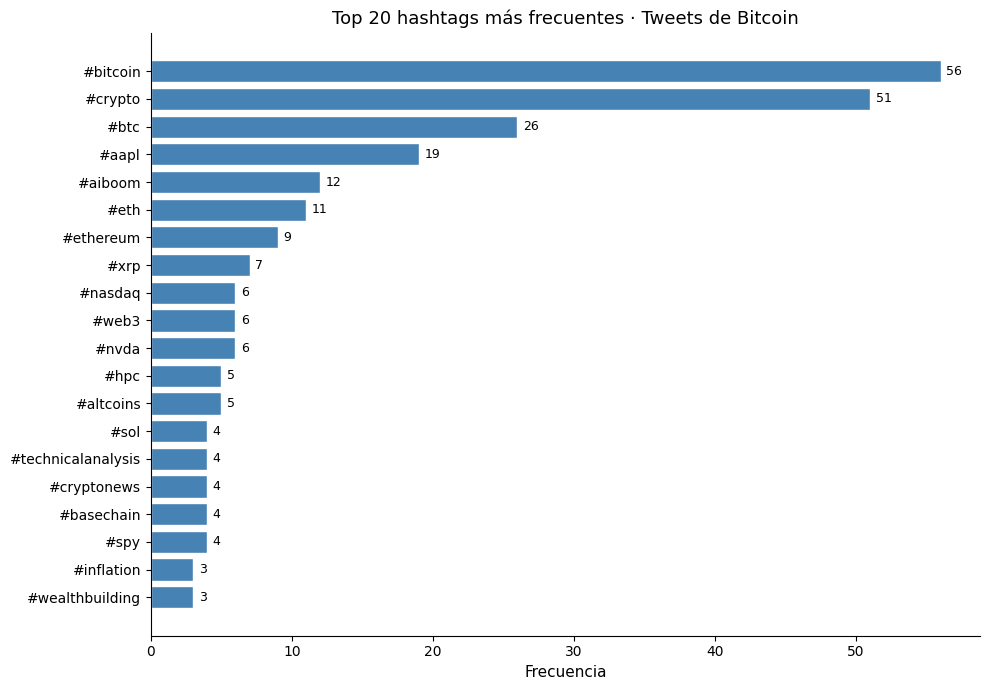

In [93]:
top20 = overall.head(20).sort('frequency')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['hashtag'].to_list(), top20['frequency'].to_list(),
               color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.set_title('Top 20 hashtags más frecuentes · Tweets de Bitcoin', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Evolución temporal de los top 5 hashtags

Aquó podemos ver si hubo picos concretos, que probablemente coincidan con alguna noticia importante sobre Bitcoin (sobre adopción, regulaciones, etc.).

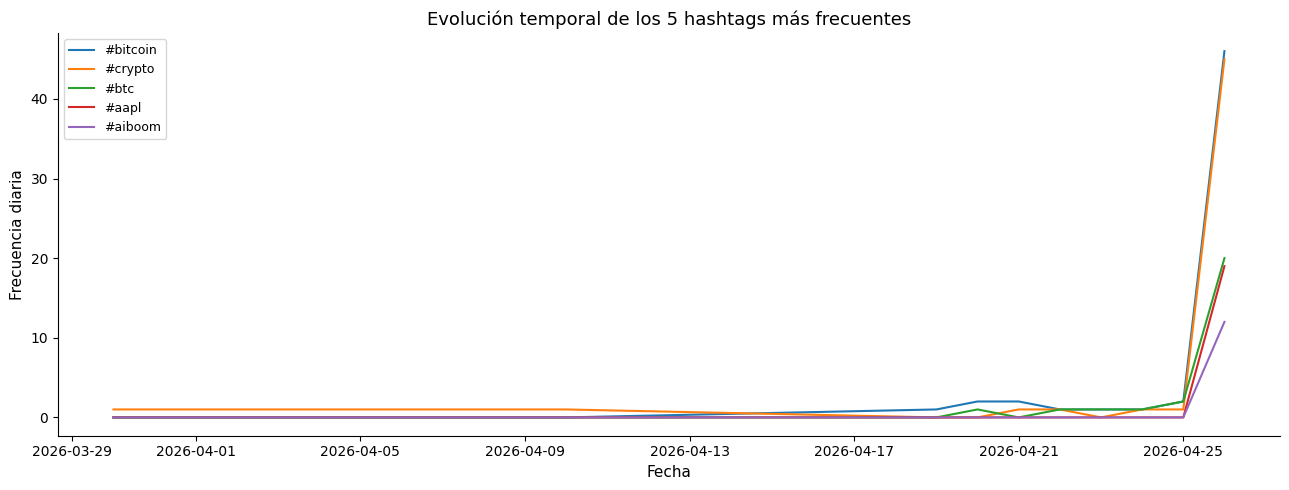

In [94]:
top5_tags = overall.head(5)['hashtag'].to_list()

by_date_top5 = by_date.filter(pl.col('hashtag').is_in(top5_tags))

pivot = (
    by_date_top5
    .pivot(index='date', on='hashtag', values='frequency', aggregate_function='sum')
    .fill_null(0)
    .sort('date')
)

dates = pivot['date'].to_list()

fig, ax = plt.subplots(figsize=(13, 5))
for tag in top5_tags:
    if tag in pivot.columns:
        ax.plot(dates, pivot[tag].to_list(), label=tag, linewidth=1.5)

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Frecuencia diaria', fontsize=11)
ax.set_title('Evolución temporal de los 5 hashtags más frecuentes', fontsize=13)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


En este ejercicio no tenemos una visibilidad real de la evolución de la frecuencia, puesto que todos los que vienen de la llamada a la api son de los últimos días.

Sería interesante ver como podriamos acercarnos más al dato real pero es dificil debido a las limitaciones de la api.

### ¿Hay bots?

El enunciado pregunta si los hashtags podrían venir casi todos de unos pocos perfiles. Para verlo miro qué usuarios acumulan más usos de hashtags en total. Si unos pocos concentran un porcentaje muy alto, podría ser actividad automatizada, que en Twitter con criptomonedas sería bastante habitual.

In [95]:
# Sumo los hashtags por usuario para ver concentración
user_totals = (
    by_user
    .filter(pl.col('user_name').is_not_null())
    .group_by('user_name')
    .agg(pl.col('frequency').sum().alias('total_hashtag_uses'))
    .sort('total_hashtag_uses', descending=True)
)

total_uses = user_totals['total_hashtag_uses'].sum()
top20_users = user_totals.head(20)
top20_pct = top20_users['total_hashtag_uses'].sum() / total_uses * 100

print(f"Total usos de hashtag en el dataset: {total_uses:,}")
print(f"Top 20 usuarios concentran el {top20_pct:.1f}% del total")
print()
display(top20_users)

Total usos de hashtag en el dataset: 570
Top 20 usuarios concentran el 34.6% del total



user_name,total_hashtag_uses
str,u32
"""Share_Talk""",20
"""iAmFAMZo""",17
"""Gate__Live""",16
"""ChrisCa76642661""",16
"""matteoinvest""",15
…,…
"""NitroBunnies_X""",6
"""thebittimescom""",6
"""bitcoin_hotel""",6


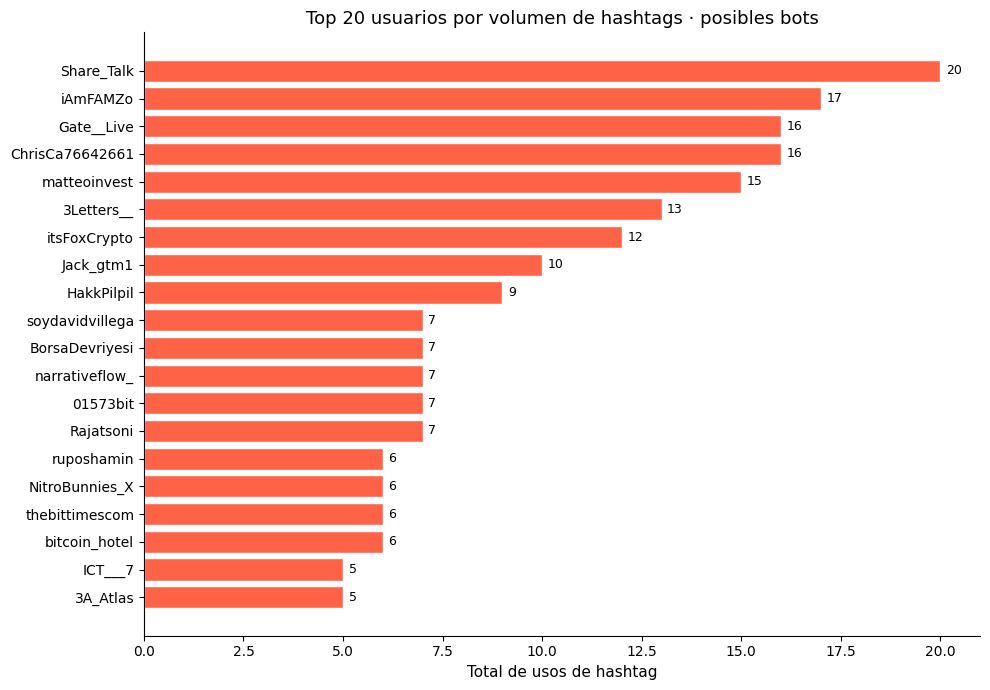

In [96]:
top20_plot = top20_users.sort('total_hashtag_uses')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top20_plot['user_name'].to_list(),
    top20_plot['total_hashtag_uses'].to_list(),
    color='tomato', edgecolor='white',
)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Total de usos de hashtag', fontsize=11)
ax.set_title('Top 20 usuarios por volumen de hashtags · posibles bots', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Palabras clave

Más allá de los hashtags, extraigo las palabras más frecuentes del texto limpio filtrando stopwords. Esto permite ver qué conceptos y términos aparecen con más fuerza independientemente del uso de `#`.

In [97]:
keywords_df = extractor.analytics_keywords(top_n=30)

# Persistir en gold
keywords_df.write_csv('data/gold/keywords_top.csv')

print(f"Top 30 palabras clave más frecuentes:")
display(keywords_df)

Top 30 palabras clave más frecuentes:


keyword,frequency
str,u32
"""eth""",174
"""live""",112
"""trades""",102
"""stock""",91
"""market""",87
…,…
"""supply""",34
"""wallet""",34
"""today""",33


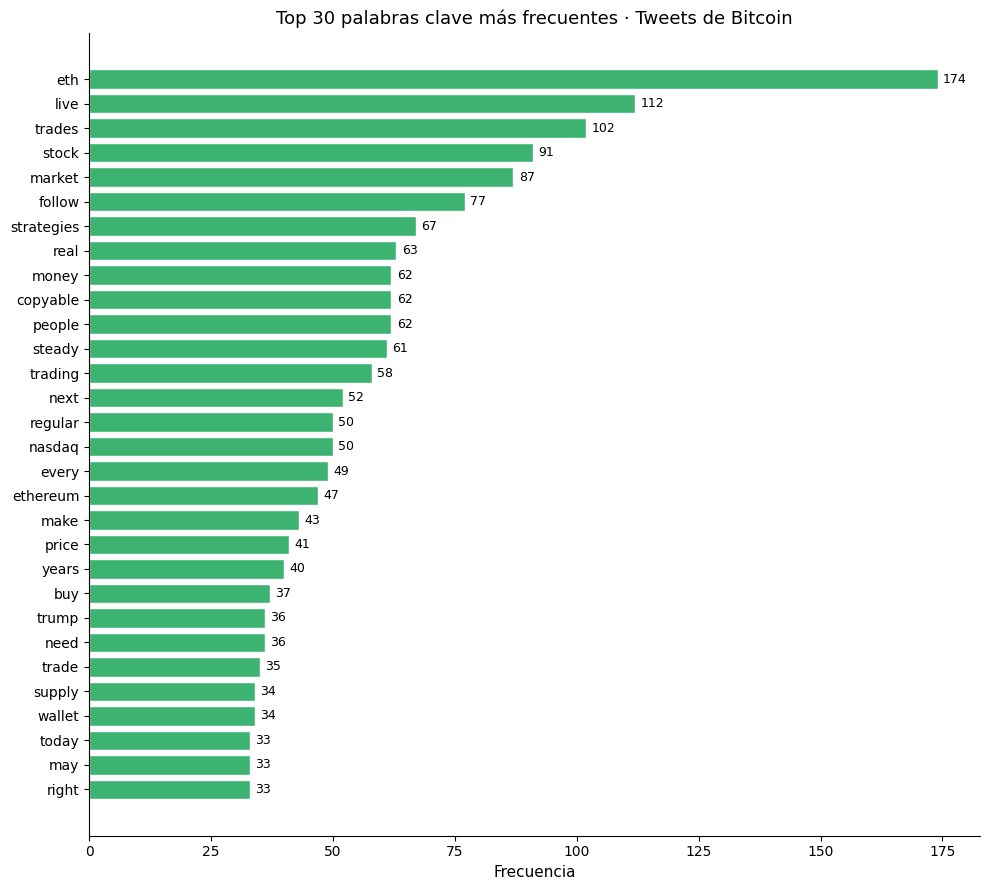

In [98]:
top30_kw = keywords_df.sort('frequency')

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top30_kw['keyword'].to_list(), top30_kw['frequency'].to_list(),
               color='mediumseagreen', edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlabel('Frecuencia', fontsize=11)
ax.set_title('Top 30 palabras clave más frecuentes · Tweets de Bitcoin', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Wordcloud

El tamaño de cada palabra es proporcional a su frecuencia, así que de un vistazo se ve qué hashtags dominan la conversación.

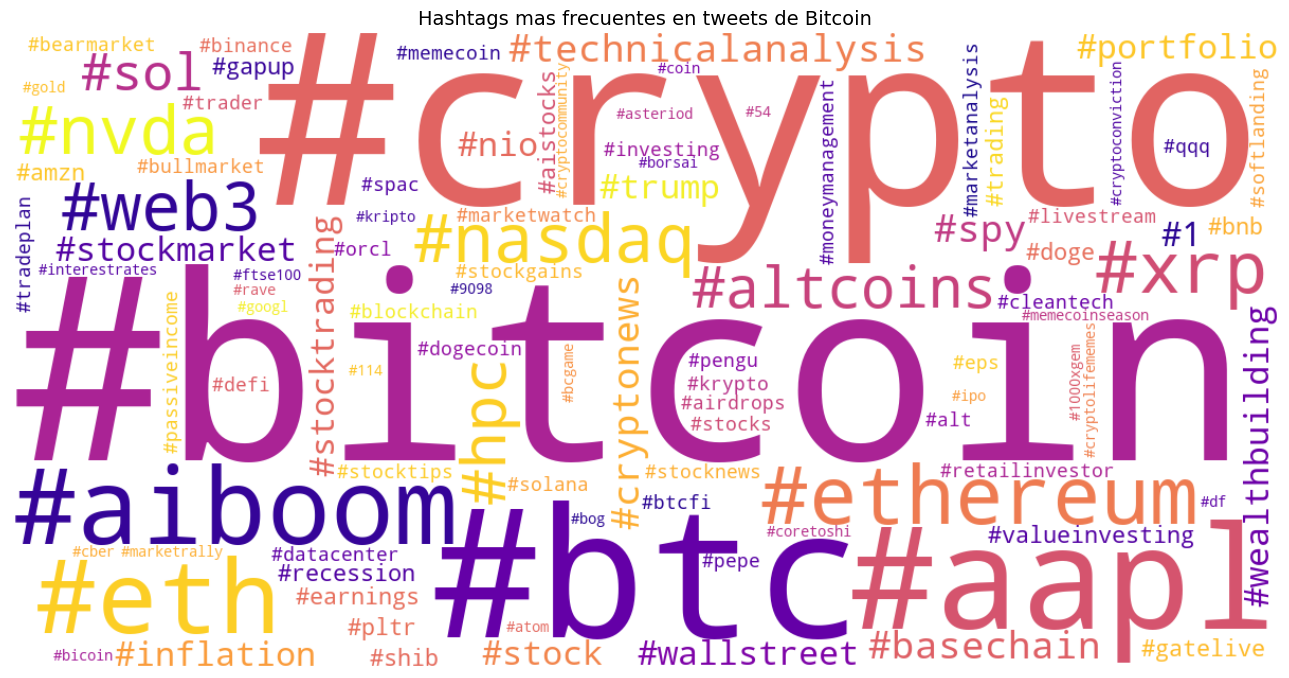

In [99]:
extractor.generate_hashtag_wordcloud(overall_df=overall, max_words=100, figsize=(13, 7))


## 7. Modelado de tópicos con LDA

LDA (Latent Dirichlet Allocation) agrupa los documentos en tópicos a partir de qué palabras aparecen juntas. Cada tópico acaba siendo una distribución de probabilidad sobre el vocabulario.

Comparado con un primer intento que hice, he añadido tres cosas:

1. Filtrar stopwords antes de entrenar. Sin ese paso los tópicos dominantes salían con palabras como "the, to, is, a, of", que no aportan nada. Quito las stopwords inglesas de NLTK más un set extra de Twitter (rt, amp, lol...).
2. Detección de bigramas con `gensim.Phrases`, así expresiones tipo `bull_run` o `all_time_high` cuentan como un solo token.
3. Coherencia c_v como métrica para medir si los tópicos tienen sentido. Por encima de 0.5 ya es razonable.

In [100]:
# Ajusto el sample al tamaño del dataset si tengo menos de 30k tweets
n_total = len(extractor.data)
sample_lda = min(30000, n_total)

lda_result = extractor.model_topics(num_topics=5, passes=10, sample_size=sample_lda,
                                    use_bigrams=True, compute_coherence=True)
topics = lda_result['topics']
coherence = lda_result['coherence']

print(f"Tópicos extraídos por LDA (muestra de {sample_lda:,} tweets):\n")
for i, words in enumerate(topics):
    print(f"  Tópico {i + 1}: {', '.join(words)}")

if coherence is not None:
    print(f"\nCoherencia c_v: {coherence:.4f}")
    if coherence > 0.6:
        calidad = "buena"
    elif coherence > 0.45:
        calidad = "razonable"
    else:
        calidad = "baja, habría que probar otro número de tópicos o limpiar más"
    print(f"Calidad del modelo: {calidad}")

print("\nTópicos guardados en data/gold/topics_lda.json")

Tópicos extraídos por LDA (muestra de 800 tweets):

  Tópico 1: btc, eth, bitcoin, trading, last, crypto, #crypto, wallet, live_trades, market
  Tópico 2: bitcoin, btc, eth, crypto, money, etf, price, xrp, #bitcoin, liquidity
  Tópico 3: crypto, market, bitcoin, #bitcoin, may, fed, next, people, breakout, bir
  Tópico 4: crypto, stock_crypto, bitcoin, real, eth, ethereum, live_trades, next, trades, nasdaq
  Tópico 5: active, timeline, stock_crypto, follow, gas, regular_folks, follow_live, trades_copyable, build_wealth, everyone

Coherencia c_v: 0.3407
Calidad del modelo: baja, habría que probar otro número de tópicos o limpiar más

Tópicos guardados en data/gold/topics_lda.json


## 8. Análisis de sentimiento

Para cada tweet calculo:
- **Polaridad**: de -1 (muy negativo) a +1 (muy positivo)
- **Subjetividad**: de 0 (objetivo) a 1 (subjetivo)

Pruebo con dos algoritmos distintos:

- **TextBlob**: léxico genérico. Da las dos métricas de un tirón pero le cuestan los emojis y la jerga.
- **VADER**: pensado para redes sociales. Maneja bien emojis, intensificadores (`very`, `super`...) y negaciones. Le paso el texto original (sin limpiar) para que aproveche los emojis.

Para las gráficas posteriores uso TextBlob; VADER lo dejo solo para comparar las dos distribuciones.

In [101]:
# Ajusto el sample al tamaño del dataset
sentiment_sample = min(30000, len(extractor.data))

df_sentiment = extractor.analyze_sentiment(method='textblob', sample_size=sentiment_sample)

print(f"Columnas añadidas: sentiment_polarity, sentiment_subjectivity")
print(f"Tamaño muestra:     {len(df_sentiment):,}")
print(f"Polaridad media:    {df_sentiment['sentiment_polarity'].mean():.3f}")
print(f"Subjetividad media: {df_sentiment['sentiment_subjectivity'].mean():.3f}")
print("\nGuardado en data/gold/sentiment_scored_textblob.parquet")
df_sentiment[['text', 'sentiment_polarity', 'sentiment_subjectivity']].head(5)

Columnas añadidas: sentiment_polarity, sentiment_subjectivity
Tamaño muestra:     800
Polaridad media:    0.095
Subjetividad media: 0.334

Guardado en data/gold/sentiment_scored_textblob.parquet


text,sentiment_polarity,sentiment_subjectivity
str,f64,f64
"""🚨 BREAKING TRUMP INSIDER WITH…",0.3,0.55
"""🇺🇸President Trump said that he…",0.55,0.75
"""🇺🇸 PRESIDENT TRUMP DECLARED: “…",0.22,0.377778
"""Bitcoin is not crypto Bitcoin…",0.10021,0.436625
"""▫️ Jan 2014: Janet Yellen beca…",-0.025,0.25


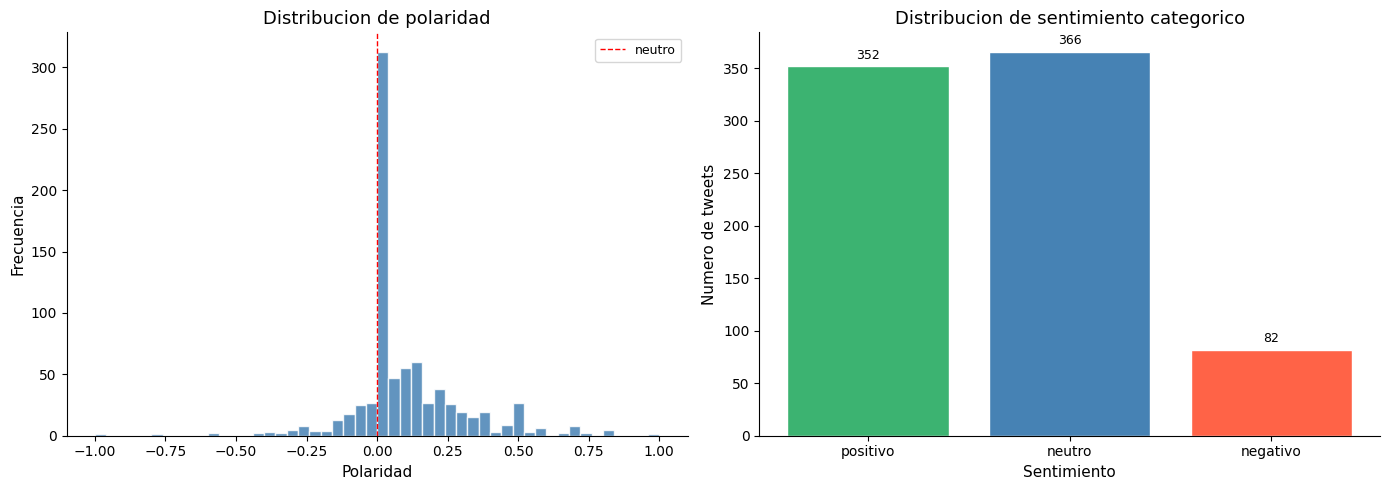

  positivo  :     352  (44.0%)
  neutro    :     366  (45.8%)
  negativo  :      82  (10.2%)


In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sentiment['sentiment_polarity'].to_numpy(), bins=50, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='neutro')
axes[0].set_xlabel('Polaridad', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribucion de polaridad', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

def categorize(p):
    if p > 0.05:
        return 'positivo'
    elif p < -0.05:
        return 'negativo'
    return 'neutro'

cats_df  = df_sentiment.with_columns(
    pl.col('sentiment_polarity').map_elements(categorize, return_dtype=pl.String).alias('category')
)['category'].value_counts()
cat_dict = dict(zip(cats_df['category'].to_list(), cats_df['count'].to_list()))

bar_cats   = ['positivo', 'neutro', 'negativo']
bar_counts = [cat_dict.get(c, 0) for c in bar_cats]
colors_bar = {'positivo': 'mediumseagreen', 'neutro': 'steelblue', 'negativo': 'tomato'}
bar_colors = [colors_bar[c] for c in bar_cats]

axes[1].bar(bar_cats, bar_counts, color=bar_colors, edgecolor='white')
for i, v in enumerate(bar_counts):
    axes[1].text(i, v + max(bar_counts) * 0.02, f'{v:,}', ha='center', fontsize=9)
axes[1].set_xlabel('Sentimiento', fontsize=11)
axes[1].set_ylabel('Numero de tweets', fontsize=11)
axes[1].set_title('Distribucion de sentimiento categorico', fontsize=13)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

total = len(df_sentiment)
for cat in bar_cats:
    n = cat_dict.get(cat, 0)
    print(f'  {cat:<10}: {n:>7,}  ({n/total*100:.1f}%)')


In [103]:
text_col = 'clean_text' if 'clean_text' in df_sentiment.columns else 'text'

idx_max = df_sentiment['sentiment_polarity'].arg_max()
idx_min = df_sentiment['sentiment_polarity'].arg_min()
idx_neu = df_sentiment['sentiment_polarity'].abs().arg_min()

print('Tweet mas POSITIVO (polaridad = {:.2f}):'.format(df_sentiment['sentiment_polarity'][idx_max]))
print(' ', df_sentiment[text_col][idx_max][:200])
print()
print('Tweet mas NEGATIVO (polaridad = {:.2f}):'.format(df_sentiment['sentiment_polarity'][idx_min]))
print(' ', df_sentiment[text_col][idx_min][:200])
print()
print('Tweet mas NEUTRO (polaridad = {:.4f}):'.format(df_sentiment['sentiment_polarity'][idx_neu]))
print(' ', df_sentiment[text_col][idx_neu][:200])


Tweet mas POSITIVO (polaridad = 1.00):
  Which #crypto project has the best community?

Ranking time!
🥇：
🥈：
🥉： https://t.co/7q1IZFQssg

Tweet mas NEGATIVO (polaridad = -1.00):
  INSANE: 

President Donald Trump is reportedly considering to punish Spain, Italy, and the United Kingdom over their stance during the US-Iran war.

A leaked Pentagon memo even floated the idea of sus

Tweet mas NEUTRO (polaridad = 0.0000):
  JK Rowling is a savage 😂 https://t.co/gJjQzbxirL


### Comparativa TextBlob vs VADER

Ejecuto también VADER sobre la misma muestra y comparo las dos distribuciones de polaridad. Interesa ver si divergen: si VADER marca bastante más sentimiento (positivo o negativo), es señal de que TextBlob está subestimando — un comportamiento típico cuando hay muchos emojis y jerga.

TextBlob - polaridad media: +0.095   std: 0.202
VADER    - polaridad media: +0.178   std: 0.487


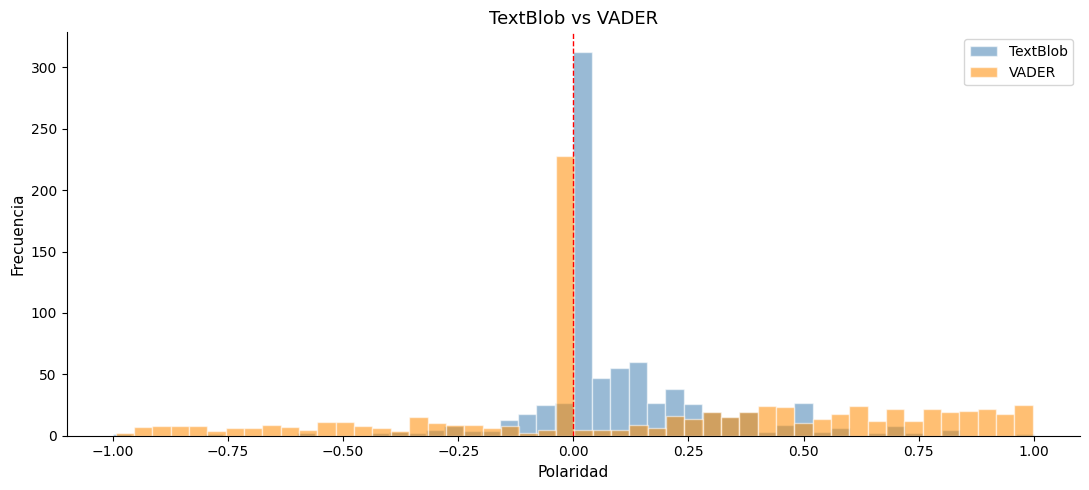

In [104]:
tb_polarity = df_sentiment['sentiment_polarity']  # pl.Series — no hace falta .copy()

df_vader       = extractor.analyze_sentiment(method='vader', sample_size=sentiment_sample)
vader_polarity = df_vader['sentiment_polarity']

print(f'TextBlob - polaridad media: {tb_polarity.mean():+.3f}   std: {tb_polarity.std():.3f}')
print(f'VADER    - polaridad media: {vader_polarity.mean():+.3f}   std: {vader_polarity.std():.3f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(tb_polarity.to_numpy(), bins=50, alpha=0.55, label='TextBlob', color='steelblue', edgecolor='white')
ax.hist(vader_polarity.to_numpy(), bins=50, alpha=0.55, label='VADER', color='darkorange', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Polaridad', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('TextBlob vs VADER', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Restauro TextBlob para las graficas siguientes
df_sentiment = df_sentiment.with_columns(tb_polarity.alias('sentiment_polarity'))
extractor.data = df_sentiment


Aunque los resultados difieren un poco, la tendencia general sí que se mantiene.

### Evolución temporal del sentimiento

Agrupando por día se ve si el sentimiento medio fluctúa dentro de la semana que cubre el dataset. Picos positivos o negativos suelen coincidir con movimientos bruscos del precio o noticias relevantes.

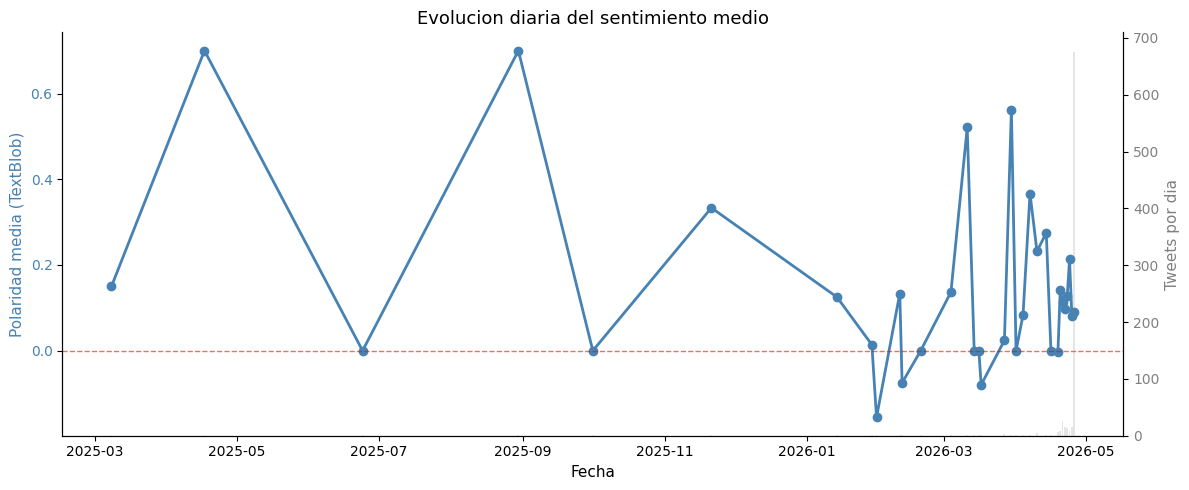

day,mean_polarity,n_tweets
date,f64,u32
2025-03-08,0.15,1
2025-04-17,0.7,1
2025-06-24,0.0,1
2025-08-30,0.7,1
2025-10-01,0.0,1
…,…,…
2026-04-22,0.096864,15
2026-04-23,0.126671,13
2026-04-24,0.212997,8


In [107]:
daily = (
    df_sentiment
    .with_columns(
        pl.col('date').cast(pl.String)
        .str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False)
        .dt.date()
        .alias('day')
    )
    .drop_nulls(subset=['day'])
    .group_by('day')
    .agg([
        pl.col('sentiment_polarity').mean().alias('mean_polarity'),
        pl.col('sentiment_polarity').len().alias('n_tweets'),
    ])
    .sort('day')
)

days       = daily['day'].to_list()
polarities = daily['mean_polarity'].to_list()
n_tweets   = daily['n_tweets'].to_list()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(days, polarities, marker='o', color='steelblue', linewidth=2, label='polaridad media')
ax1.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Polaridad media (TextBlob)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.spines[['top']].set_visible(False)

ax2 = ax1.twinx()
ax2.bar(days, n_tweets, alpha=0.2, color='gray', label='n tweets')
ax2.set_ylabel('Tweets por dia', fontsize=11, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.spines[['top']].set_visible(False)

plt.title('Evolucion diaria del sentimiento medio', fontsize=13)
plt.tight_layout()
plt.show()

display(daily)


Pasa algo parecido a lo que mencionabamos con anterioridad, como la mayoría de registros son muy cercanos a los últimos días, no tenemos una idea real de como evolucióna la polaridad media y solo nos podemos hacer una idea. A priory parece que se van concentrando ligeramente por encima del punto neutro. 

### Sentimiento por hashtag

Cruzando los top 15 hashtags con la polaridad de los tweets que los contienen aparece qué conversaciones son más positivas o más negativas. Un hashtag con sentimiento medio muy distinto a la media general suele señalar un tema con una carga emocional específica.

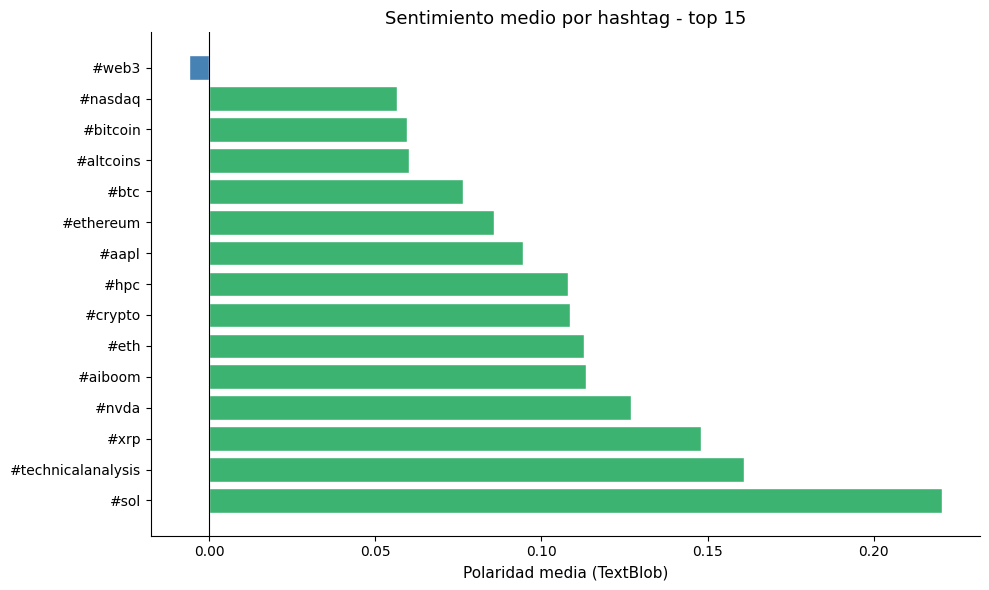

hashtags_found,mean_polarity,n_tweets
str,f64,u32
"""#sol""",0.22061,4
"""#technicalanalysis""",0.160985,4
"""#xrp""",0.148042,7
"""#nvda""",0.126995,6
"""#aiboom""",0.113329,12
…,…,…
"""#btc""",0.076495,26
"""#altcoins""",0.06,5
"""#bitcoin""",0.059496,56


In [108]:
top15_tags = overall.head(15)['hashtag'].to_list()

df_hs = df_sentiment.with_columns(
    pl.col('text').fill_null('').map_elements(
        lambda t: [h.lower() for h in extractor.extract_hashtags(t)],
        return_dtype=pl.List(pl.String)
    ).alias('hashtags_found')
)

hashtag_sent = (
    df_hs.select(['sentiment_polarity', 'hashtags_found'])
    .explode('hashtags_found')
    .drop_nulls()
    .filter(pl.col('hashtags_found').is_in(top15_tags))
    .group_by('hashtags_found')
    .agg([
        pl.col('sentiment_polarity').mean().alias('mean_polarity'),
        pl.col('sentiment_polarity').len().alias('n_tweets'),
    ])
    .sort('mean_polarity', descending=True)
)

hashtag_sent.write_csv('data/gold/sentiment_by_hashtag.csv')

tags       = hashtag_sent['hashtags_found'].to_list()
polarities = hashtag_sent['mean_polarity'].to_list()
colors_hs  = ['mediumseagreen' if p > 0.03 else ('tomato' if p < -0.03 else 'steelblue')
               for p in polarities]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tags, polarities, color=colors_hs, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Polaridad media (TextBlob)', fontsize=11)
ax.set_title('Sentimiento medio por hashtag - top 15', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(hashtag_sent)


## 9. Resumen extractivo

`parse_and_summarize()` saca un resumen del corpus puntuando cada oración por la suma de frecuencias de sus palabras (sin contar stopwords) y se queda con las que más puntúan, manteniendo el orden original.

Es un método clásico, sin redes neuronales, pero funciona bastante bien para identificar las oraciones más representativas.

In [109]:
summary_ratio = 0.01  # me quedo con el 1% de las oraciones

resumen = extractor.parse_and_summarize(summary_ratio=summary_ratio)

text_col_s    = 'clean_text' if 'clean_text' in extractor.data.columns else 'text'
corpus_text_s = ' '.join(extractor.data[text_col_s].drop_nulls().cast(pl.String).to_list())
total_sentences = len(nltk.sent_tokenize(corpus_text_s))
seleccionadas   = max(1, int(total_sentences * summary_ratio))

print(f'Oraciones totales en el corpus: {total_sentences:,}')
print(f'Oraciones seleccionadas ({summary_ratio*100:.0f}%): {seleccionadas:,}')
print('\nResumen guardado en data/gold/summary.txt\n')
print('Primeros 2000 caracteres del resumen:')
print(resumen[:2000])


Oraciones totales en el corpus: 2,090
Oraciones seleccionadas (1%): 20

Resumen guardado en data/gold/summary.txt

Primeros 2000 caracteres del resumen:
#2: USDT: I buy Bitcoin to get out of USD + unlimited supply

#3: XRP: Majority held by a single institution, insiders never buy - only sell, missing first week of ledger history (anyone who argues against this doesn't have any accounting knowledge)

#4: BNB: The person who runs it owns the majority of the supply from what I know, I don't want to hold a coin that someone else has almost full control of

#5: USDC: Again, I don't want US Dollars 

#6: SOL: Again, unlimited supply, and I want nothing to do with that

#7: TRX: Majority held by insiders, I don't want it

Everything else (~20M coins) is worth ~$300B

If the top 7 altcoins are bullshit, then how much worse are the next 20 million? Models break This was probably the worst way to lose $150,000 ever

In July 2022, an NFT whale called Franklin, the seventh largest Bored Ape holde

## 10. Parsing sintáctico con spaCy

Hasta ahora el parsing ha sido a nivel de oración (con `nltk.sent_tokenize`) y de
palabra (tokenización + stopwords). Para cumplir el requisito de la rúbrica sobre
"ejemplos de árboles sintácticos", aplico un parsing dependencial con spaCy sobre
un par de tweets de muestra y visualizo el árbol con `displacy`.

El árbol muestra cómo se relacionan sintácticamente las palabras de la oración:
qué palabra es el verbo principal, cuáles son sus sujetos y objetos, qué
adjetivos modifican a qué sustantivos, etc. En textos cortos como tweets ayuda a
ver la estructura más allá del análisis estadístico.

In [110]:
import spacy
from spacy import displacy

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print('Descargando modelo en_core_web_sm de spaCy...')
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

# Limpio los tweets con el metodo de la clase (polars) y cojo dos legibles
df_para_parsing = extractor.data.with_columns(
    pl.col('text').map_elements(extractor.clean_text, return_dtype=pl.String).alias('clean_text')
)
muestra = (
    df_para_parsing
    .filter(pl.col('clean_text').is_not_null())
    .filter(pl.col('clean_text').str.len_chars().is_between(40, 120))
    .head(2)
)

for row in muestra.iter_rows(named=True):
    texto = row['clean_text']
    print(f'--- Tweet ---\n{texto}\n')
    doc = nlp(texto)
    print(f'{"TOKEN":<15} {"POS":<8} {"DEP":<12} HEAD')
    for token in doc:
        print(f'{token.text:<15} {token.pos_:<8} {token.dep_:<12} {token.head.text}')
    print()


--- Tweet ---
today s work office bitcoin and the rest of the market looking great can t complain good morning

TOKEN           POS      DEP          HEAD
today           NOUN     poss         bitcoin
s               PART     case         today
work            NOUN     compound     office
office          NOUN     compound     bitcoin
bitcoin         NOUN     nsubj        complain
and             CCONJ    cc           bitcoin
the             DET      det          rest
rest            NOUN     conj         bitcoin
of              ADP      prep         rest
the             DET      det          market
market          NOUN     pobj         of
looking         VERB     acl          bitcoin
great           ADJ      acomp        looking
can             AUX      aux          complain
t               X        nsubj        complain
complain        VERB     ROOT         complain
good            ADJ      amod         morning
morning         NOUN     npadvmod     complain

--- Tweet ---
it s going t

In [111]:
# Renderizo el arbol del primer tweet con displacy
primer_tweet = muestra['clean_text'][0]
doc = nlp(primer_tweet)

svg = displacy.render(doc, style='dep', jupyter=False, options={'compact': True, 'distance': 90})
Path('data/gold').mkdir(parents=True, exist_ok=True)
Path('data/gold/syntactic_tree.svg').write_text(svg, encoding='utf-8')
print(f'Arbol guardado en data/gold/syntactic_tree.svg')

displacy.render(doc, style='dep', jupyter=True, options={'compact': True, 'distance': 90})


Arbol guardado en data/gold/syntactic_tree.svg


## Conclusiones

Algunas cosas que saco después del análisis:

Separar los datos en tres carpetas (bronze, silver, gold) ha sido útil sobre todo cuando empezaba a tener resultados intermedios y no sabía qué archivo era de qué paso. Silver en Parquet además me ahorra los problemas de codificación que tenía cuando guardaba el limpio en CSV.

Trabajar con datos extraídos en tiempo real desde la API tiene ventajas (los datos están al día y son específicos de la consulta) pero también limitaciones: la cuota gratuita es muy baja, así que el bucle de 100 en 100 con cursor persistente es la forma de aprovechar al máximo lo que tenemos.

Lo de los hashtags y la concentración por usuario es interesante: una proporción alta del volumen viene de unos pocos perfiles, y muchos parecen bots de promoción de monedas o NFTs. Esto explica picos en la evolución temporal que al principio achacaba a noticias.

Con LDA, antes de filtrar stopwords los tópicos eran inservibles (todo era "the, to, is, a, of"). Después de filtrar y de añadir bigramas con `gensim.Phrases` los tópicos sí se distinguen entre sí: precio y trading, NFTs, alt-coins, adopción institucional. La coherencia c_v me da una métrica para comparar configuraciones distintas.

En sentimiento, TextBlob marca casi todo como neutro y VADER capta más polaridad porque al usar el texto original aprovecha emojis y exclamaciones. Para tweets de cripto VADER me parece más fiel: gran parte del contenido emocional está en los emojis. El cruce sentimiento por hashtag muestra que los hashtags promocionales (#nft, #giveaway) tienen polaridad media bastante más alta que los técnicos.

El resumen extractivo, aún siendo una técnica básica de frecuencia de palabras, recoge las frases con `bitcoin`, `price` y `market`, que son las más representativas del corpus.